In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as stats 
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import time
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import GroupKFold
from sklearn.impute import KNNImputer
from haversine import haversine
from sklearn.neighbors import BallTree

In [36]:
print("Current working directory:", os.getcwd())
df = pd.read_csv("../../../data/finaldatasets/testdata/RFgdpadded.csv")

print(list(df.columns))

df = df[df["Grain.yield..tons.ha.1."] <= 100]

df.to_csv("../../../data/finaldatasets/testdata/RFgdpadded12-7.csv", index=False)

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering


/tmp/ipykernel_170190/1879132457.py:2: DtypeWarning: Columns (6,7,13,14,15,16,17,20,22,23,29,31,33,34,35,36,37,44,45,69,70,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/finaldatasets/testdata/RFgdpadded.csv")


['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soil_N', 'pr_irrigated', 'AEZ', 'Elevation', 'temp1', 'temp2', 'temp3', 'temp4', 'temp5', 'temp6', 'temp7', 'temp8', 'temp9', 'prc1', 'prc2', 'p

##### Generate plots to see if yield is normally distributed

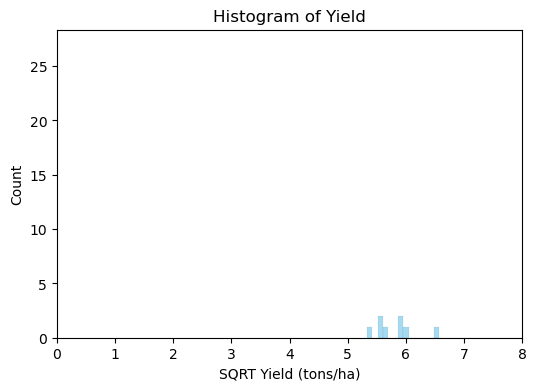

In [25]:
#Histogram of yield (yield values filtered to below 100 and square-rooted for better visualization)
y = np.sqrt(df["Grain.yield..tons.ha.1."].dropna())
y = y[y < 100]  # Filter out extreme values for better visualization

plt.figure(figsize=(6, 4))
sns.histplot(y, kde=False, bins=1000, color='skyblue')
plt.title("Histogram of Yield")
plt.xlabel("SQRT Yield (tons/ha)")
plt.xlim(0,8)
plt.grid(False)
plt.show()

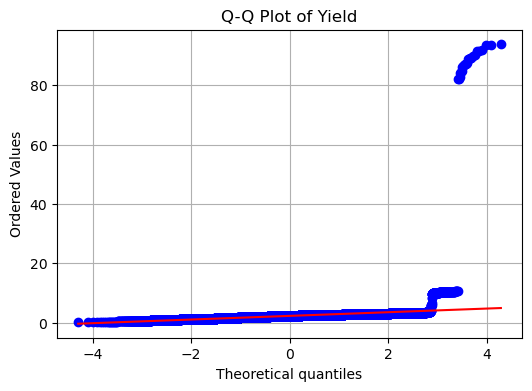

In [20]:
# Q-Q plot of yield to check normality

plt.figure(figsize=(6, 4))
stats.probplot(y, dist="norm", plot=plt)
plt.title("Q-Q Plot of Yield")
plt.grid(True)
plt.show()

In [35]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   78013 |          100   |      77619 |
| Location.source                                       | object  |   78013 |          100   |          9 |
| year                                                  | int64   |   78013 |          100   |         42 |
| Elevation                                             | float64 |   78013 |          100   |        202 |
| Data.ID                                               | object  |   78013 |          100   |         54 |
| end_date                                              | int64   |   78013 |          100   |         10 |
| start_date                                            | int64   |   78013 |          100   |          7 |
| Grain.yield..tons.ha.1.   

In [ ]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude",

HIGH_CARDINALITY_COLS = [
    "Crop.variety", "Treatment.type", "Emissions..yes.no.",
    "N.type", "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66"
]

COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# Drop each group of columns sequentially for clarity
df_no_location = df.drop(columns=[col for col in LOCATION_COLS if col in df.columns])
df_no_high_card = df_no_location.drop(columns=[col for col in HIGH_CARDINALITY_COLS if col in df_no_location.columns])
df_cleaned = df_no_high_card.drop(columns=[col for col in COLLINEAR_COLS if col in df_no_high_card.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped location columns:", [col for col in LOCATION_COLS if col in df.columns])
print("Dropped high-cardinality columns:", [col for col in HIGH_CARDINALITY_COLS if col in df.columns])
print("Dropped collinear columns:", [col for col in COLLINEAR_COLS if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 30 percent completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

Original shape: (78147, 89)
Shape after dropping: (78147, 65)
Dropped location columns: ['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Location.source', 'Observation.period']
Dropped high-cardinality columns: ['Crop.variety', 'Treatment.type', 'Emissions..yes.no.', 'N.type', 'Irrigation..mm.', 'Harvesting.date.1', 'Pest.severity.score.......66']
Dropped collinear columns: ['harvest_month', 'harvest_date_clean', 'harvest_week', 'Planting.date', 'Planting_Month', 'Planting.date.1', 'Planting_Week']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Wheat.Type', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'N.fertilizer.management', 'P.type', 'P.rate..kg.P.ha.1.', 'Straw.return', 'Plastic.film.

In [33]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


Soil.type               51
Tillage.type            23
Treatment_Category      14
Wheat.Type               8
irrigation_applied       4
Treatment                2
Pest.prescence....64     2
dtype: int64

RF with spacial and temporal blocking? 

In [11]:
#prepare data

df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])

X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

X['lon'] = df_cleaned['Conversion.for.longitude']
X['lat'] = df_cleaned['Conversion.for.latitude']


#handling imputation for categorical columns
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].fillna("Missing").astype(str)
    X[col] = LabelEncoder().fit_transform(X[col])


#handling imputation for continous columns 
X = X.dropna(axis=1, thresh=int(0.95 * len(X)))
# --- KNN Imputation with k=2 ---
imputer = KNNImputer(n_neighbors=2)
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [15]:
### --- BLOCK 2: Spatial Grouping (Haversine Clustering) ---

# Ensure coordinates are present and valid
coords = df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().values

# Convert degrees to radians
coords_rad = np.deg2rad(coords)

# Build BallTree with haversine metric
tree = BallTree(coords_rad, metric='haversine')

# Radius = 100 km converted to radians
radius_km = 100
radius = radius_km / 6371.0  # Earth radius ≈ 6371 km

# Track visited indices and groups
groups = []
visited = np.zeros(len(coords), dtype=bool)

for i in range(len(coords)):
    if not visited[i]:
        inds = tree.query_radius([coords_rad[i]], r=radius)[0]
        groups.append(inds)
        visited[inds] = True

# Assign group label to each sample
spatial_group_labels = np.zeros(len(coords), dtype=int)
for group_id, inds in enumerate(groups):
    spatial_group_labels[inds] = group_id

# Assign group labels back to the cleaned dataframe (ensure alignment)
df_cleaned.loc[df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().index, 'spatial_group'] = spatial_group_labels


In [17]:
# --- BLOCK 3: Temporal Grouping (By Year) ---
temporal_groups = df_cleaned['year'].astype(str).values  # Adjust to match your time column

# --- BLOCK 4: Combined Spatial + Temporal Groups ---
combined_groups = np.array([
    f"S{int(spatial)}_T{temporal}" 
    for spatial, temporal in zip(df_cleaned['spatial_group'], temporal_groups)
])


In [21]:

### --- BLOCK 5: Cross-Validation + Model Training ---
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

baseline = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=0,
    n_jobs=os.cpu_count() - 1,
    criterion="absolute_error"
)

cv = GroupKFold(n_splits=5)
cv_results = cross_validate(
    baseline, X, y,
    cv=cv.split(X, y, groups=combined_groups),
    scoring=scoring,
    return_train_score=True
)

print(f"Train MAE: {-np.mean(cv_results['train_mae']):.4f}")
print(f"Val MAE: {-np.mean(cv_results['test_mae']):.4f}")
print(f"Train RMSE: {-np.mean(cv_results['train_rmse']):.4f}")
print(f"Val RMSE: {-np.mean(cv_results['test_rmse']):.4f}")
print(f"Train R²: {np.mean(cv_results['train_r2']):.4f}")
print(f"Val R²: {np.mean(cv_results['test_r2']):.4f}")

### --- BLOCK 6: Optional Visualisation ---
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y, y=baseline.fit(X, y).predict(X), alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(y - baseline.predict(X), bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.grid(True)
plt.show()

Train MAE: 1.0185
Val MAE: 10.4787
Train RMSE: 4.3487
Val RMSE: 135.8856
Train R²: 0.9990
Val R²: -2682.2923


KeyboardInterrupt: 

<Figure size 600x600 with 0 Axes>

Bog standard RF

Train MAE: 0.7778
Val MAE: 4.9631
Train RMSE: 3.6929
Val RMSE: 65.2011
Train R²: 0.9901
Val R²: -2.1125


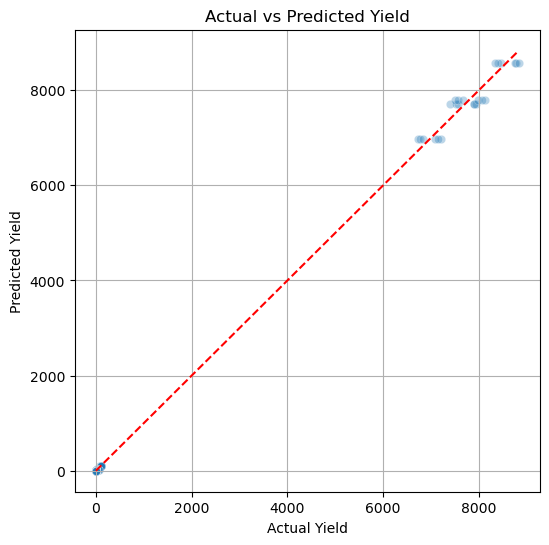

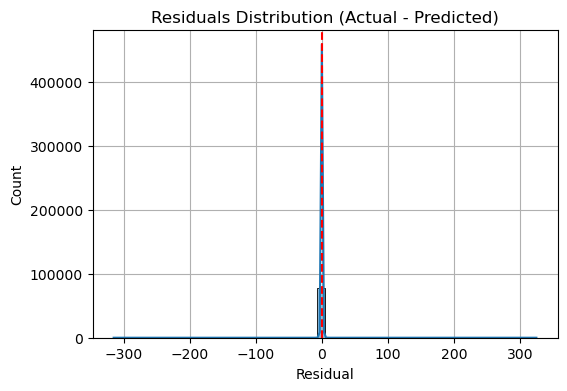

In [ ]:
#Create copy of dataset and then select predictor variable as Y

# Drop unnamed column if present
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]

# Drop rows with missing yield
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])

X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

# Handle categorical variables (label encode for RF)
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].fillna("Missing").astype(str)
    X[col] = LabelEncoder().fit_transform(X[col])

# Drop columns with too many missing values
X = X.dropna(axis=1, thresh=int(0.8 * len(X)))

# Impute remaining numeric columns with median
X = X.fillna(X.median(numeric_only=True))

# --- Model definition ---
baseline = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=0,
    n_jobs=os.cpu_count() - 1,
    criterion="absolute_error"
)

# --- Cross-validation with multiple metrics ---
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv_results = cross_validate(
    baseline, X, y, cv=5, scoring=scoring, return_train_score=True
)

# Print train/test metrics
print(f"Train MAE: {-np.mean(cv_results['train_mae']):.4f}")
print(f"Val MAE: {-np.mean(cv_results['test_mae']):.4f}")
print(f"Train RMSE: {-np.mean(cv_results['train_rmse']):.4f}")
print(f"Val RMSE: {-np.mean(cv_results['test_rmse']):.4f}")
print(f"Train R²: {np.mean(cv_results['train_r2']):.4f}")
print(f"Val R²: {np.mean(cv_results['test_r2']):.4f}")

# --- Fit on full data for plotting ---
baseline.fit(X, y)
y_pred = baseline.predict(X)
residuals = y - y_pred

# --- Actual vs Predicted Plot ---
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.3)
plt.xlim(-30, 30)
plt.ylim(-30, 30)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid(True)
plt.show()

# --- Residuals Plot ---
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.xlim(-10,10)
plt.grid(True)
plt.show()

